# Monte Carlo Integration
# Stock Price Application


In [1]:
# Standard modules
import numpy as np
import yfinance as yf
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
from scipy.integrate import dblquad
from numpy.random import default_rng
rng = default_rng()

# Settings for Matplotlib plots
plt.style.use(['seaborn-v0_8-talk','seaborn-v0_8-darkgrid','seaborn-v0_8-colorblind'])
plt.rc('image',cmap='viridis')               # Default colour map 
plt.rc('figure',figsize=(8,5))               # Default figure dimensions in inches
plt.rc('figure.constrained_layout',use=True) # Default figure layout option
plt.rc('legend',frameon=True,framealpha=1.0) # Default appearance of figure legend
plt.rc('hist',bins=100)                      # Default number of bins to use in histograms

Brownian motion is the macroscopic picture emerging from a particle moving randomly in d-dimensional space.
All random walks whose displacements have the same mean and covariance matrix give rise to same macroscopic process, and even the assumption that the displacements have to be independent and identically distributed can be substantially relaxed.
This effect is called universality, and the macroscopic process is often called a universal object.

You sample one random number per time step from a standard normal distribution — mean 0, standard deviation 1 — and use it to generate the next price from the current price. The lognormal distribution isn't something you sample from directly; it's what emerges after you build up the price path this way.

You plug Z into this formula to step the price forward by one time increment Δt:

\begin{equation*}
S(t+\Delta t ) = S(t) \cdot e^{(r-\frac{\sigma ^2}{2}+\sigma\sqrt{\Delta t}Z)}
\end{equation*}

- S(t) — current price (known)
- r — risk-free interest rate (a chosen constant, e.g. 0.04 for 4%)
- σ — volatility (a chosen constant, e.g. 0.25 for 25% annualized — this is the "how random" knob)
- Δt — size of the time step (e.g. 1/252 for one trading day, if there are 252 trading days/year)
- Z — the standard normal sample you just drew

When you price an option via Monte Carlo, the answer is an integral over all possible values of the final stock price:

Option price = \begin{equation} e^{(−rT)} · ∫ P(S_T) · f(S_T) dS_T \end{equation}

where f(S_T) is the lognormal probability density function of the final stock price, and the integral runs over all possible values S_T could take (0 to ∞).

Instead of directly drawing a lognormal S_T value from f(S_T) using the sampling techniques, you draw a standard normal Z and transform it through the GBM formula.

That transformation — \begin{equation} S_T = S_0 · e^{(r − σ²/2)T + σ√T·Z} \end{equation} — is itself a change-of-variables sampling method for the lognormal distribution.

Step by Step 

1. Sample — draw Z ~ N(0,1), transform to get S_T (a sample from the lognormal distribution)
2. Evaluate — compute payoff(S_T) — e.g. max(S_T − K, 0) for a call
3. Average — repeat steps 1-2 across N simulated paths, average the payoffs: (1/N)Σ payoff(S_T,i)
4. Discount — multiply by e^(−rT) to bring the future expected payoff back to today's present value

In [20]:
asset = 'BP'

df = yf.download(asset)['Close']

df = df.squeeze() 

df_pct = df.pct_change().dropna()
#print(df_pct)

mean = float(df_pct.mean())
vol = float(df_pct.std())
last_price = float(df.iloc[-1])
print(last_price)
periods = 252

[*********************100%***********************]  1 of 1 completed

43.970001220703125


In [21]:
def Monte_Carlo_example(period=252, n_scenarios=1000, mu=mean, sigma=vol, last_price=last_price):

    # Inputs
    dt = 1 # here we can use sub_periods if we want to predict for years
    n_steps = int(period)
    xi = np.random.normal(size=(n_steps, n_scenarios)) # 1. Sample 
    rets = mu*dt + sigma*np.sqrt(dt)*xi # Geometric Brownian motion (GBM) 
    # which is used to describe the random
    # evolution of stock prices over time
    rets = pd.DataFrame(rets)

    # to prices
    prices = last_price*(1+rets).cumprod()
    return prices

/var/folders/s_/hgby3j4n2hd0tww8yrmkq5z40000gp/T/ipykernel_30804/1428473587.py:6: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


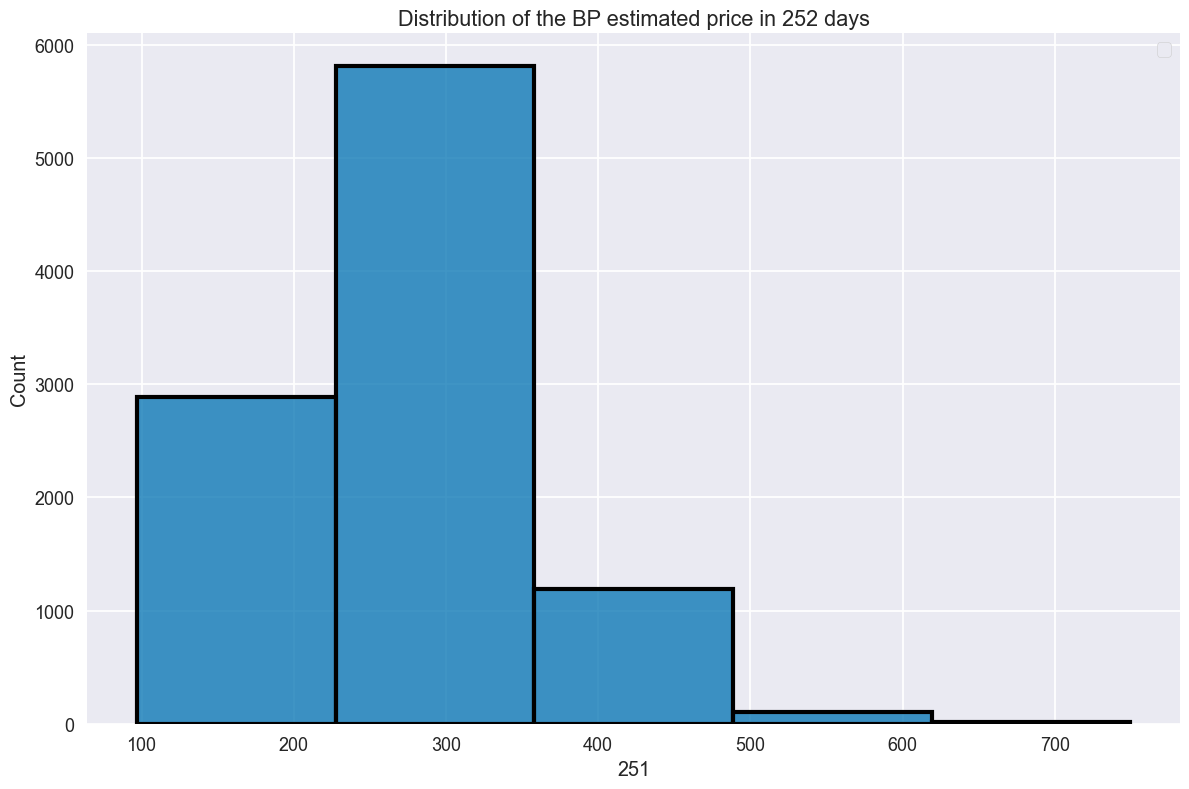

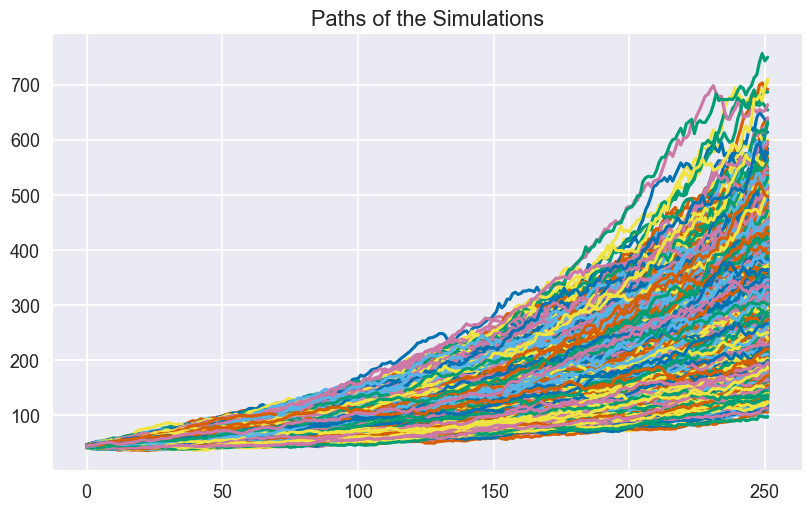

In [24]:
sim = Monte_Carlo_example(period=periods, n_scenarios=10000, mu=mean, sigma=vol, last_price=last_price)

plt.figure(figsize=(12,8), tight_layout=False)

ax = sns.histplot(data=sim.iloc[-1, :], bins=5, linewidth=3)
ax.legend()

ax.set(title=f'Distribution of the {asset} estimated price in 252 days');

sim.plot(legend=False, title='Paths of the Simulations');

In [23]:
final_prices = sim.iloc[-1, :]

print(f"Mean expected price:     {final_prices.mean():.2f}")
print(f"Median expected price:   {final_prices.median():.2f}")
print(f"Std deviation:           {final_prices.std():.2f}")
print(f"5th percentile (bad case):  {final_prices.quantile(0.05):.2f}")
print(f"95th percentile (good case): {final_prices.quantile(0.95):.2f}")

Mean expected price:     274.75
Median expected price:   265.24
Std deviation:           76.06
5th percentile (bad case):  169.44
95th percentile (good case): 414.04


Why the significant increase in price : 

1. The drift (mean) is estimated over decades of history : 

yf.download(asset) with no start date pulls AAPL's entire trading history, back to 1980. Over that span, AAPL has grown from a fraction of a dollar (split-adjusted) to hundreds of dollars — so the historical daily average return baked into mean reflects 40+ years of extraordinary compounding growth, not AAPL's current, more moderate growth trajectory. Feeding that inflated daily drift forward for "the next 252 days" massively overstates where the price is likely to go.

Fix can be achieved by a more representative window:

python
df = yf.download(asset, period='2y')['Close'].squeeze()

2. Missing the variance drag correction (the actual GBM formula) : 

True Geometric Brownian Motion is:

S(t+Δt) = S(t) · exp[(μ − σ²/2)·Δt + σ√Δt·Z]

The −σ²/2 term corrects for the fact that volatility itself drags down the compounded growth rate relative to the simple average return. 

3. Compounding arithmetic returns multiplicatively amplifies the bias : 

Code compounds using (1+rets).cumprod() — repeatedly multiplying (1 + daily return) across 252 steps. This is mathematically different from compounding log-returns (which is what the real GBM formula above does via exp(...) and summed log-terms).


In [26]:
# applying corrections 

df = yf.download(asset, period='2y')['Close'].squeeze()

df = df.squeeze() 

df_pct = df.pct_change().dropna()
#print(df_pct)

mean = float(df_pct.mean())
vol = float(df_pct.std())
last_price = float(df.iloc[-1])
print(last_price)
periods = 252

def Monte_Carlo_corrected(period=252, n_scenarios=1000, mu=mean, sigma=vol, last_price=last_price):
    dt = 1
    n_steps = int(period)
    xi = np.random.normal(size=(n_steps, n_scenarios))

    # True GBM log-return formula, with variance drag correction
    log_rets = (mu - 0.5 * sigma**2) * dt + sigma * np.sqrt(dt) * xi
    log_rets = pd.DataFrame(log_rets)

    # Convert log-returns to a price path via exp(cumulative sum), not (1+r).cumprod()
    prices = last_price * np.exp(log_rets.cumsum())
    return prices

[*********************100%***********************]  1 of 1 completed

43.78499984741211


/var/folders/s_/hgby3j4n2hd0tww8yrmkq5z40000gp/T/ipykernel_30804/367076120.py:6: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


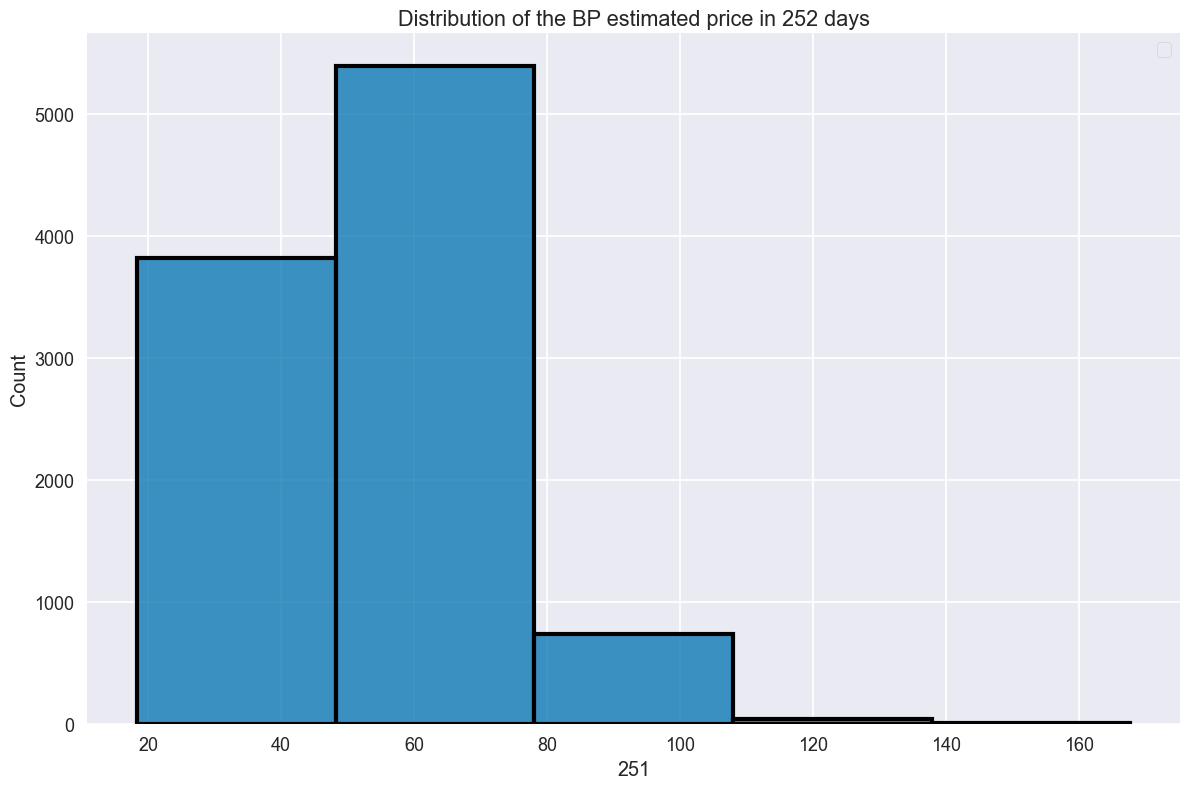

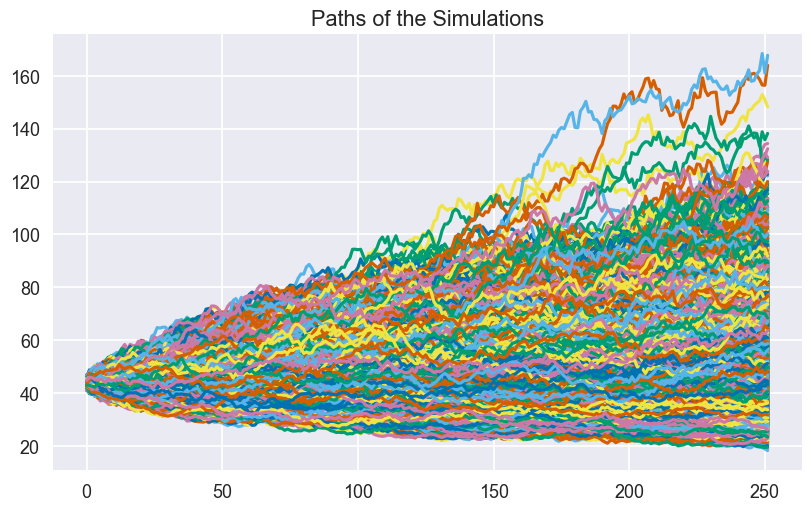

In [27]:
sim = Monte_Carlo_corrected(period=periods, n_scenarios=10000, mu=mean, sigma=vol, last_price=last_price)

plt.figure(figsize=(12,8), tight_layout=False)

ax = sns.histplot(data=sim.iloc[-1, :], bins=5, linewidth=3)
ax.legend()

ax.set(title=f'Distribution of the {asset} estimated price in 252 days');

sim.plot(legend=False, title='Paths of the Simulations');

In [28]:
final_prices = sim.iloc[-1, :]

print(f"Mean expected price:     {final_prices.mean():.2f}")
print(f"Median expected price:   {final_prices.median():.2f}")
print(f"Std deviation:           {final_prices.std():.2f}")
print(f"5th percentile (bad case):  {final_prices.quantile(0.05):.2f}")
print(f"95th percentile (good case): {final_prices.quantile(0.95):.2f}")

Mean expected price:     54.45
Median expected price:   52.25
Std deviation:           15.50
5th percentile (bad case):  33.07
95th percentile (good case): 83.13
